# Signature-transform forecasting on a public labor-market dataset

This notebook applies the signature-transform forecasting framework to a fully public weekly dataset built from FRED. The target is **U.S. initial jobless claims in levels**, while the covariates remain public macro and market series available at daily or weekly frequency. As in notebook 1, the model is trained to forecast **future changes over each horizon**, that is, $y_{t+h} - y_t$, rather than the raw future level directly.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd

from marketplace_signature_forecast.config import (
    ALL_HORIZONS,
    DEFAULT_DEPTH,
    DEFAULT_N_TARGET,
    DEFAULT_WINDOW_SIZE,
    FRED_API_KEY,
)
from marketplace_signature_forecast.data_loading import (
    build_data_dictionary_from_specs,
    fetch_series_bundle,
)
from marketplace_signature_forecast.dataset_specs import (
    INITIAL_CLAIMS_END_DATE,
    INITIAL_CLAIMS_EXPERIMENT_NAME,
    INITIAL_CLAIMS_FRED_INPUTS,
    INITIAL_CLAIMS_N_VALIDATION,
    INITIAL_CLAIMS_PLOT_HORIZON,
    INITIAL_CLAIMS_RESAMPLE_FREQ,
    INITIAL_CLAIMS_START_DATE,
    INITIAL_CLAIMS_TARGET,
    INITIAL_CLAIMS_YAHOO_INPUTS,
)
from marketplace_signature_forecast.preprocessing import (
    build_model_dataset,
    prepare_standardized_arrays,
    resample_collection,
    resample_to_weekly,
    save_processed_bundle,
    train_validation_split,
)
from marketplace_signature_forecast.adaptive_weights import rolling_adaptive_weights
from marketplace_signature_forecast.baselines import forecast_arima, forecast_naive
from marketplace_signature_forecast.evaluation import (
    build_forecast_dataframe,
    inverse_transform_forecasts,
    run_multi_horizon_experiment,
)
from marketplace_signature_forecast.modeling import rolling_forecast
from marketplace_signature_forecast.plotting import (
    plot_adaptive_weight_diagnostics,
    plot_correlation_matrix,
    plot_forecast_vs_actual,
    plot_input_grid,
    plot_target_split,
    plot_weights_for_origin,
)

TARGET_COL = INITIAL_CLAIMS_TARGET["name"]
TARGET_LABEL = INITIAL_CLAIMS_TARGET["name"]
PUBLIC_EXPERIMENT_NAME = INITIAL_CLAIMS_EXPERIMENT_NAME

DATASET_DIR = PROJECT_ROOT / "data" / "processed" / PUBLIC_EXPERIMENT_NAME
FIGURE_DIR = PROJECT_ROOT / "figures" / PUBLIC_EXPERIMENT_NAME
Y_ONLY_DIR = DATASET_DIR / "signature_y_only"
JOINT_DIR = DATASET_DIR / "signature_joint_path"

for directory in [DATASET_DIR, FIGURE_DIR, Y_ONLY_DIR, JOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

data_dictionary = build_data_dictionary_from_specs(
    target=INITIAL_CLAIMS_TARGET,
    fred_inputs=INITIAL_CLAIMS_FRED_INPUTS,
    yahoo_inputs=INITIAL_CLAIMS_YAHOO_INPUTS,
)
target_mask = data_dictionary["type"].eq("target (y)")
data_dictionary.loc[target_mask, "variable"] = TARGET_COL
data_dictionary.loc[target_mask, "description"] = "U.S. initial jobless claims in levels"
data_dictionary.loc[target_mask, "frequency"] = "Weekly, ending Saturday"
data_dictionary.loc[target_mask, "code"] = INITIAL_CLAIMS_TARGET["code"]
data_dictionary

,variable,type,source,code,description,frequency
0,initial_claims,target (y),FRED,ICSA,U.S. initial jobless claims in levels,"Weekly, ending Saturday"
1,continued_claims,input (x),FRED,CCSA,Continued Claims (Insured Unemployment),"Weekly, Ending Saturday"
2,nfci,input (x),FRED,NFCI,Chicago Fed National Financial Conditions Index,Weekly
3,vix,input (x),FRED,VIXCLS,CBOE Volatility Index,Daily
4,term_spread,input (x),FRED,T10Y2Y,10-Year Treasury Constant Maturity Minus 2-Yea...,Daily
5,sp500,input (x),FRED,SP500,S&P 500 Index,Daily
6,wti_crude,input (x),FRED,DCOILWTICO,WTI Crude Oil Spot Price,Daily
7,effr,input (x),FRED,FEDFUNDS,Effective Federal Funds Rate,Monthly


## 1. Download, align, and save the weekly dataset

All series are resampled to the same weekly calendar ending on Saturday so that the target and covariates share a common forecasting grid.  
The target remains in **levels**. As in the original consumer-loans notebook, the forecasting task is formulated in terms of **future changes over horizon $h$**, not direct prediction of the raw future level.

In [2]:
y_raw, x_raw = fetch_series_bundle(
    api_key=FRED_API_KEY,
    target=INITIAL_CLAIMS_TARGET,
    start=INITIAL_CLAIMS_START_DATE,
    end=INITIAL_CLAIMS_END_DATE,
    fred_inputs=INITIAL_CLAIMS_FRED_INPUTS,
    yahoo_inputs=INITIAL_CLAIMS_YAHOO_INPUTS,
)

y_weekly = resample_to_weekly(y_raw, freq=INITIAL_CLAIMS_RESAMPLE_FREQ)
y_target = y_weekly.rename(columns={INITIAL_CLAIMS_TARGET["name"]: TARGET_COL})

x_weekly = resample_collection(x_raw, freq=INITIAL_CLAIMS_RESAMPLE_FREQ)
full_data = build_model_dataset(y_target, x_weekly).dropna().copy()
train_data, validation_data = train_validation_split(full_data, INITIAL_CLAIMS_N_VALIDATION)

save_processed_bundle(full_data, train_data, validation_data, data_dictionary, DATASET_DIR)

print(full_data.shape)
print(full_data.index.min(), full_data.index.max())
full_data.head()

(105, 8)
2016-04-02 00:00:00 2024-12-07 00:00:00


,initial_claims,continued_claims,nfci,vix,term_spread,sp500,wti_crude,effr
date,,,,,,,,
2016-04-02,273000.0,2151000.0,-0.37710,13.10,1.03,2072.78,35.36,0.37
2016-05-07,289000.0,2185000.0,-0.38356,14.72,1.05,2057.14,44.58,0.37
2016-06-04,265000.0,2170000.0,-0.36780,13.47,0.93,2099.13,48.69,0.38
2016-07-02,255000.0,2131000.0,-0.34471,14.77,0.87,2102.95,49.02,0.39
2016-08-06,265000.0,2157000.0,-0.36073,11.39,0.87,2182.87,41.83,0.40


## 2. Exploratory analysis

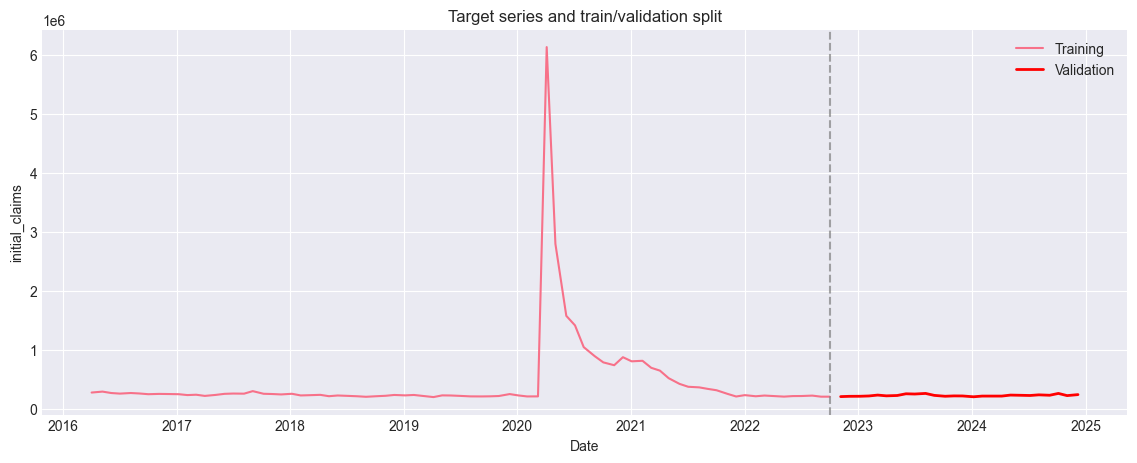

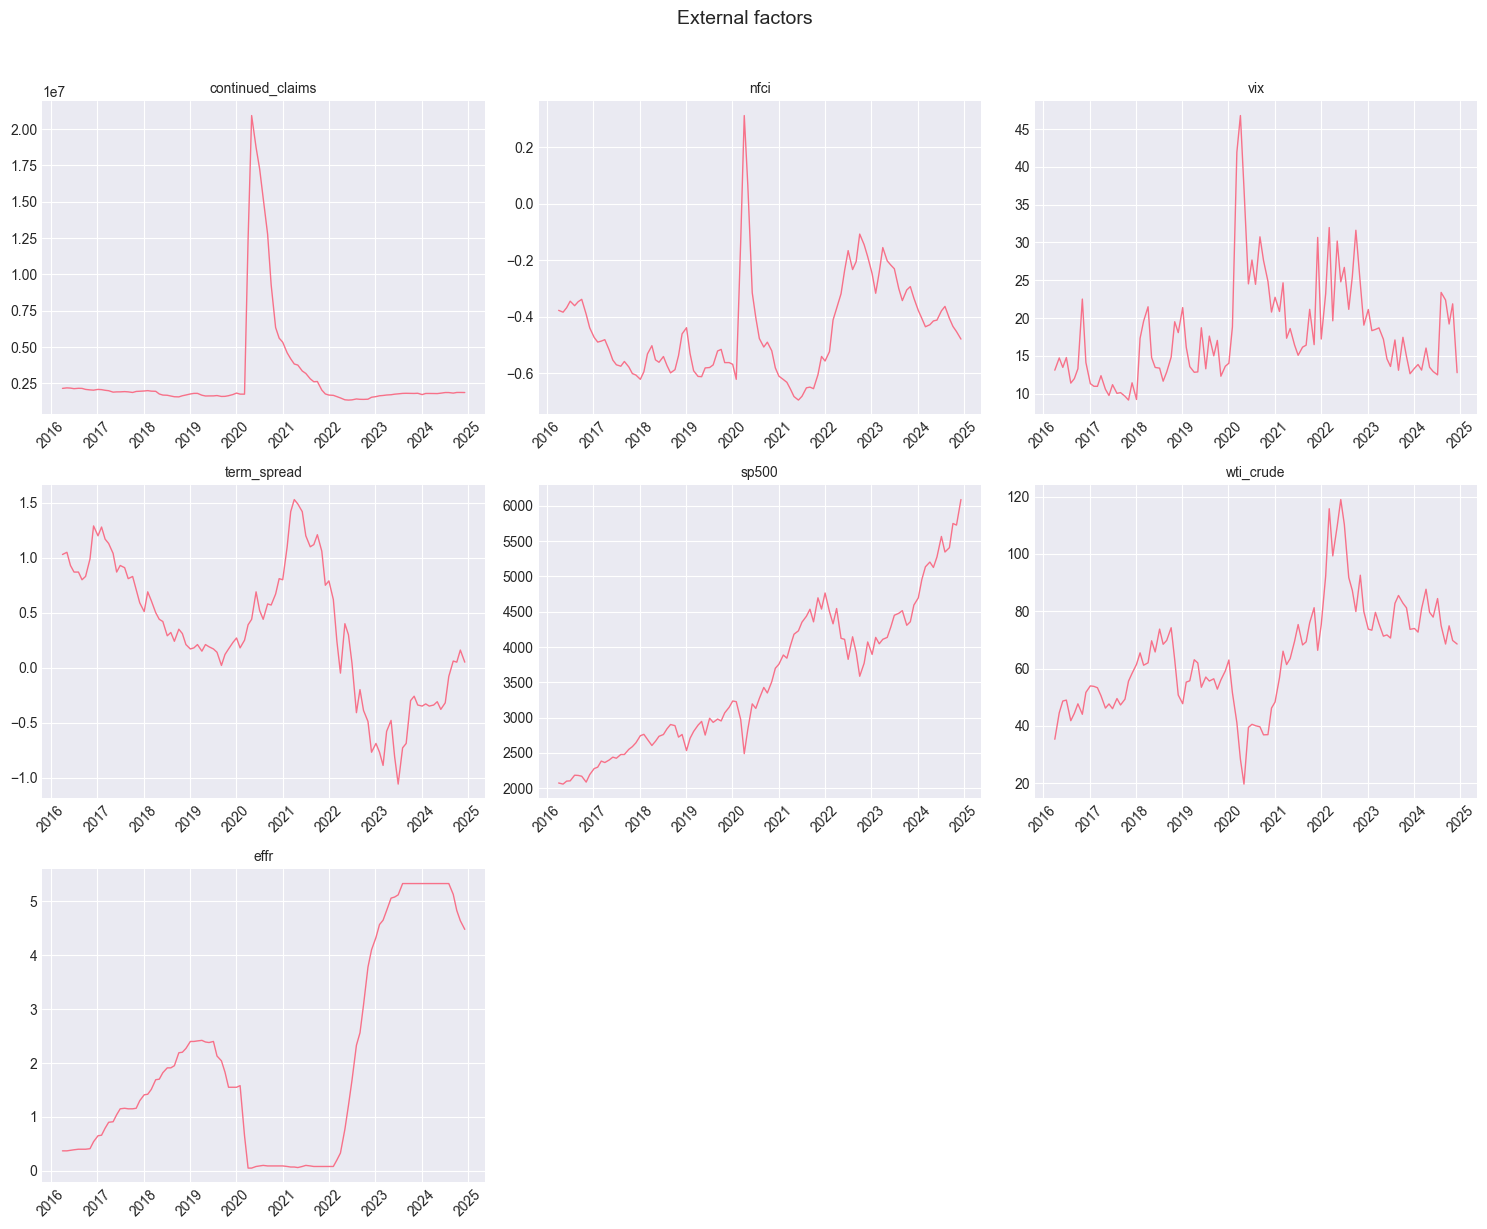

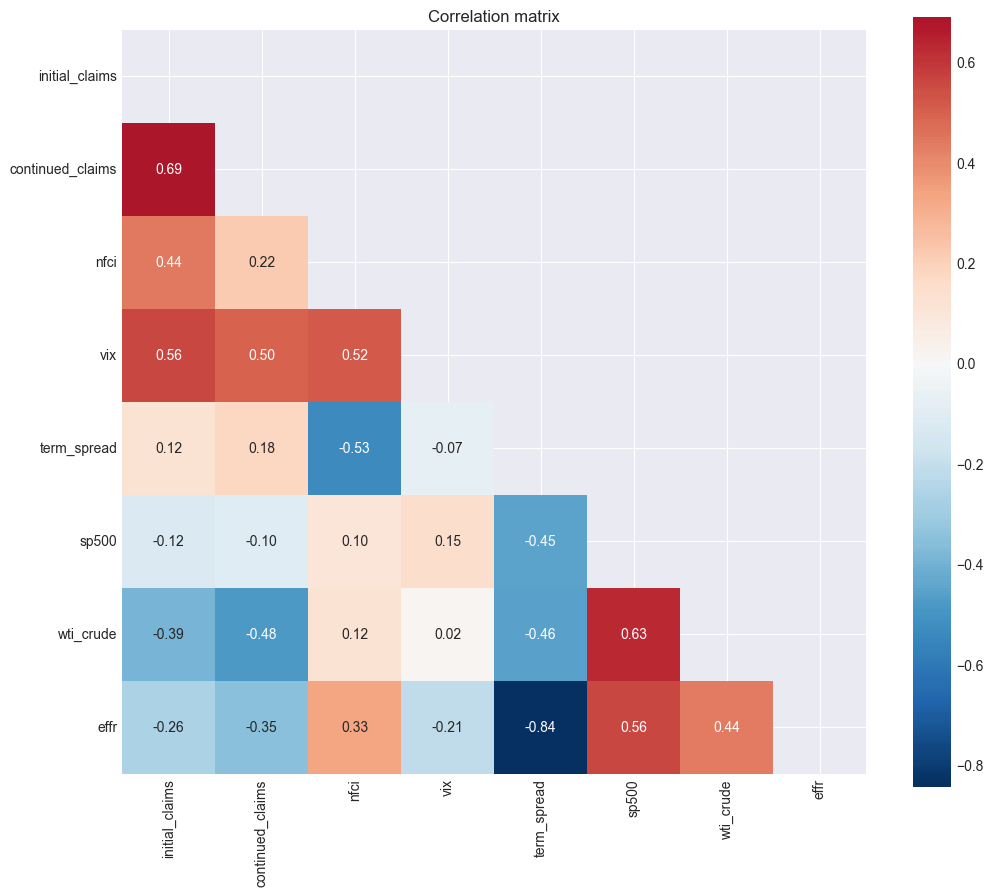

,initial_claims,continued_claims,nfci,vix,term_spread,sp500,wti_crude,effr
count,105.000,1.050000e+02,105.000,105.000,105.000,105.000,105.000,105.000
mean,392028.571,2.935771e+06,-0.445,18.010,0.356,3530.371,64.338,2.012
std,659779.224,3.543549e+06,0.170,6.889,0.611,1022.348,18.378,1.895
min,196000.000,1.344000e+06,-0.694,9.140,-1.060,2057.140,19.720,0.050
25%,214000.000,1.680000e+06,-0.572,13.110,0.020,2706.530,50.540,0.370
50%,230000.000,1.821000e+06,-0.481,16.420,0.320,3271.120,63.120,1.550
75%,257000.000,2.080000e+06,-0.347,21.150,0.830,4328.870,74.990,3.080
max,6137000.000,2.093900e+07,0.312,46.800,1.530,6090.270,118.970,5.330


In [3]:
plot_target_split(train_data, validation_data, TARGET_COL, FIGURE_DIR / "target_variable.png")
plot_input_grid(full_data, TARGET_COL, FIGURE_DIR / "input_variables.png")
plot_correlation_matrix(full_data, FIGURE_DIR / "correlation_matrix.png")

full_data.describe().round(3)

## 3. Standardized modeling arrays

In [4]:
prepared = prepare_standardized_arrays(
    full_data=full_data,
    target_col=TARGET_COL,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
)

X = prepared["X"]
y = prepared["y"]
y_raw_array = prepared["y_raw"]
dates = prepared["dates"]
y_scaler = prepared["y_scaler"]
train_end_t = prepared["train_end"]

WINDOW_SIZE = DEFAULT_WINDOW_SIZE
DEPTH = DEFAULT_DEPTH
N_TARGET = DEFAULT_N_TARGET

print(X.shape, y.shape, train_end_t)

(105, 7) (105,) 67


## 4. Adaptive-weight diagnostics

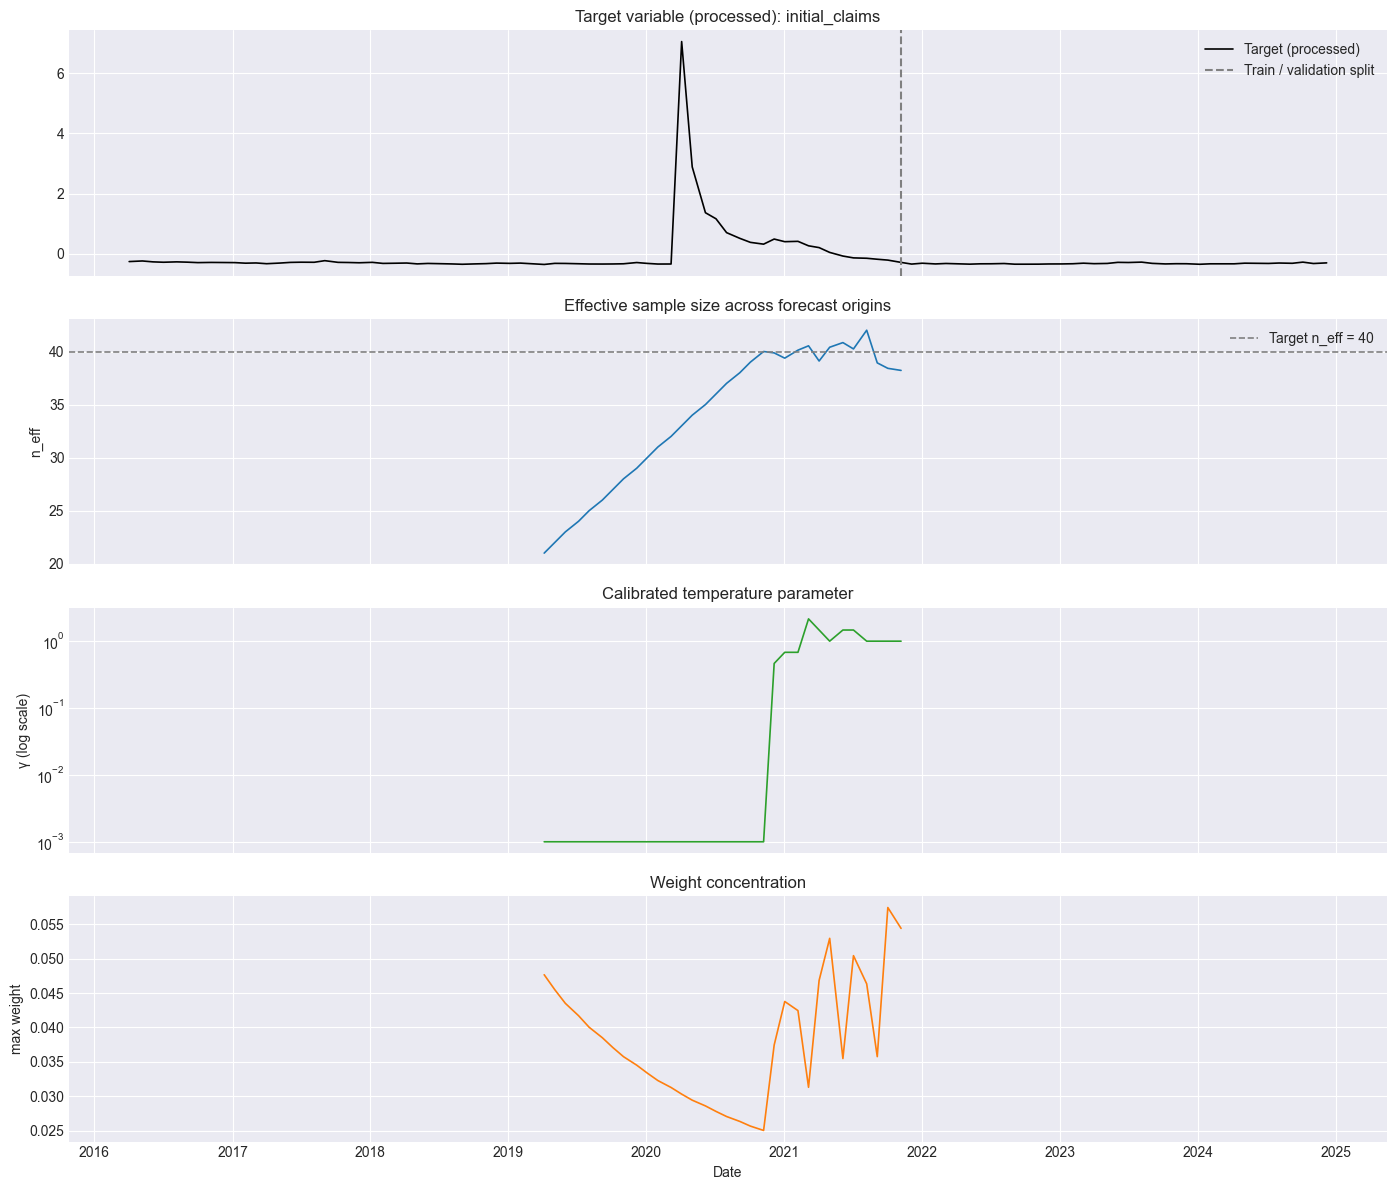

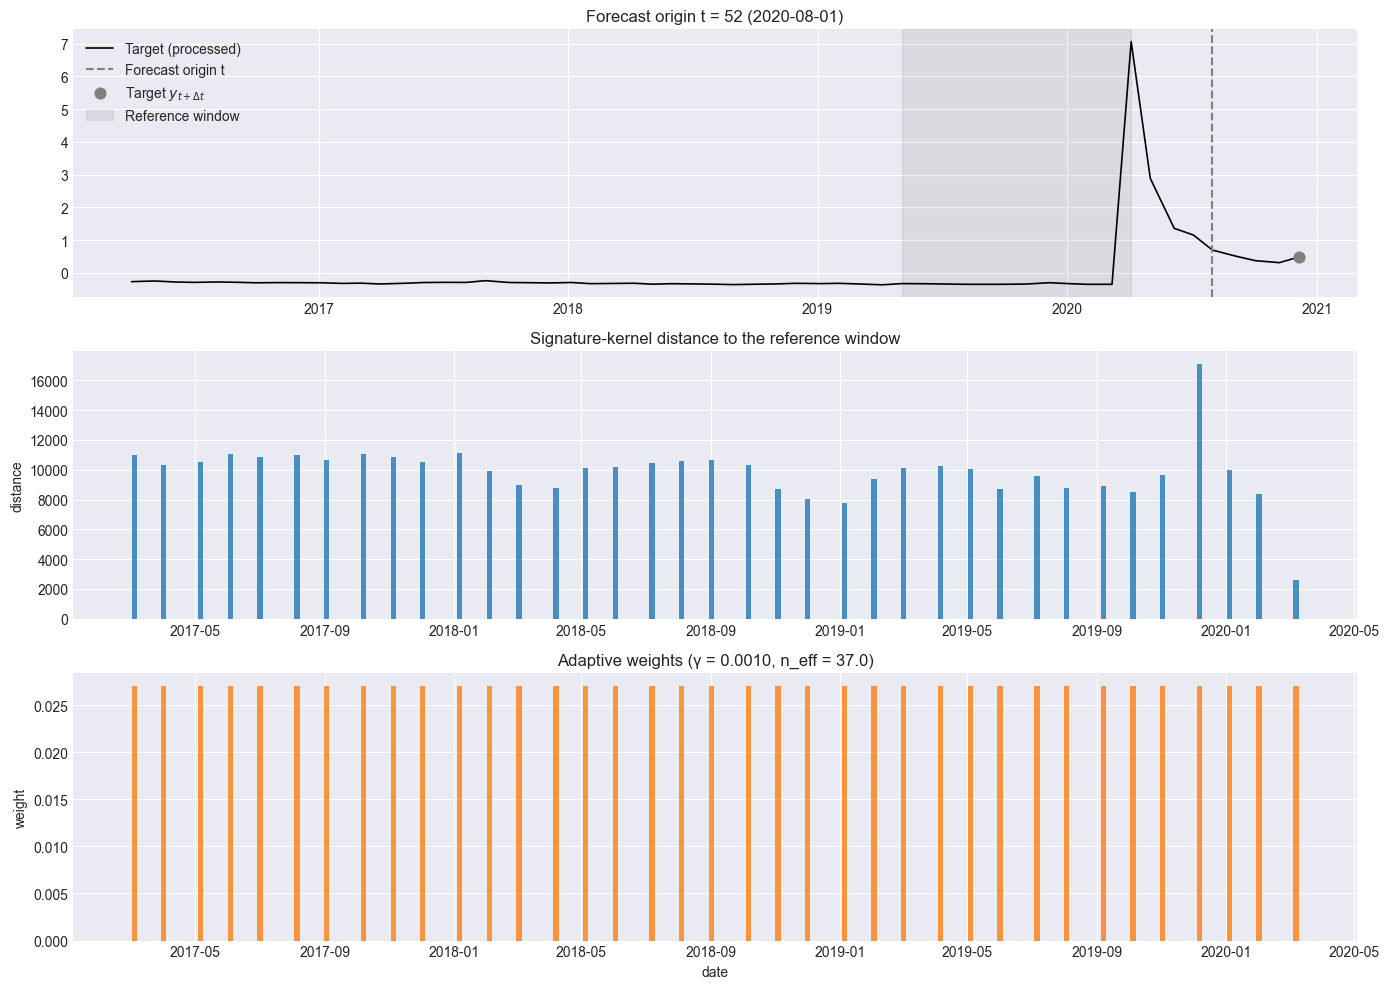

In [5]:
diagnostic_horizon = INITIAL_CLAIMS_PLOT_HORIZON
min_t = WINDOW_SIZE + diagnostic_horizon + 20

adaptive_results = rolling_adaptive_weights(
    X=X,
    y=y,
    start_t=min_t,
    end_t=train_end_t,
    delta_t=diagnostic_horizon,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    gamma=None,
    n_target=N_TARGET,
    add_time=True,
)

plot_adaptive_weight_diagnostics(adaptive_results, dates, y, train_end_t, N_TARGET, TARGET_COL)
plot_weights_for_origin(adaptive_results, len(adaptive_results["t"]) // 2, X, y, dates, diagnostic_horizon, WINDOW_SIZE, DEPTH)

## 5. Multi-horizon point forecasts: target-path signature only

In [6]:
results_y_only, _ = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=Y_ONLY_DIR,
    lambda_lasso=None,
    gamma=None,
    use_sig_y_only=True,
    add_time=True,
)

summary_y_only = pd.DataFrame(
    [
        {
            "horizon_weeks": horizon,
            "signature_y_only_mae": results_y_only[horizon]["mae"],
            "signature_y_only_rmse": results_y_only[horizon]["rmse"],
            "signature_y_only_mre": results_y_only[horizon]["mre"],
            "n_forecasts": len(results_y_only[horizon]["t"]),
        }
        for horizon in sorted(results_y_only)
    ]
)
summary_y_only

,horizon_weeks,signature_y_only_mae,signature_y_only_rmse,signature_y_only_mre,n_forecasts
0,1,24094.607524,31155.223610,10.972583,26
1,2,58474.836766,83236.404415,26.465595,26
2,3,130842.875316,173228.034288,58.618244,26
3,4,187179.778659,233143.409802,83.667691,26
4,6,340249.943049,442829.980681,154.193722,26
5,8,507688.936708,615821.993889,224.778776,26
6,12,747357.933179,885246.134306,339.394321,26


## 6. Multi-horizon point forecasts: joint-path signature

In [7]:
results_joint, _ = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=JOINT_DIR,
    lambda_lasso=None,
    gamma=None,
    use_sig_y_only=False,
    add_time=True,
)

summary_joint = pd.DataFrame(
    [
        {
            "horizon_weeks": horizon,
            "signature_joint_mae": results_joint[horizon]["mae"],
            "signature_joint_rmse": results_joint[horizon]["rmse"],
            "signature_joint_mre": results_joint[horizon]["mre"],
            "n_forecasts": len(results_joint[horizon]["t"]),
        }
        for horizon in sorted(results_joint)
    ]
)
summary_joint

c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.115e-04, tolerance: 7.486e-05
  model = cd_fast.enet_coordinate_descent(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.869e-05, tolerance: 8.719e-05
  model = cd_fast.enet_coordinate_descent(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

,horizon_weeks,signature_joint_mae,signature_joint_rmse,signature_joint_mre,n_forecasts
0,1,1.399541e+05,3.983823e+05,64.695106,26
1,2,3.565985e+06,6.413714e+06,1557.603520,26
2,3,2.046141e+07,4.037203e+07,9064.974402,26
3,4,3.323922e+07,4.571804e+07,14750.576780,26
4,6,3.810301e+07,6.072484e+07,16749.652728,26
5,8,3.073888e+07,4.542840e+07,14157.233546,26
6,12,2.228471e+07,4.113212e+07,10032.334295,26


## 7. Baseline comparison

Because the model forecasts **changes in the level series**, MAE and RMSE are useful scale-sensitive diagnostics, especially when realized changes can be small.  
The table below therefore reports **MAE** and **RMSE** as the main point-forecast metrics, while keeping MRE as a secondary diagnostic.

In [8]:
baseline_rows = []
val_end = len(y_raw_array) - 1

for delta_t in ALL_HORIZONS:
    val_start = len(y_raw_array) - INITIAL_CLAIMS_N_VALIDATION - delta_t

    actual_naive, forecast_naive_values = forecast_naive(y_raw_array, val_start, val_end - delta_t, delta_t)
    actual_arima, forecast_arima_values = forecast_arima(y_raw_array, val_start, val_end - delta_t, delta_t)

    if len(actual_naive) == 0:
        continue

    baseline_rows.append(
        {
            "Horizon (weeks)": delta_t,
            "Naive MAE": float(np.mean(np.abs(forecast_naive_values - actual_naive))),
            "Naive RMSE": float(np.sqrt(np.mean((forecast_naive_values - actual_naive) ** 2))),
            "ARIMA MAE": float(np.mean(np.abs(forecast_arima_values - actual_arima))) if len(actual_arima) else np.nan,
            "ARIMA RMSE": float(np.sqrt(np.mean((forecast_arima_values - actual_arima) ** 2))) if len(actual_arima) else np.nan,
        }
    )

baseline_table = pd.DataFrame(baseline_rows)

comparison_table = baseline_table.merge(
    summary_y_only[["horizon_weeks", "signature_y_only_mae", "signature_y_only_rmse", "signature_y_only_mre"]],
    left_on="Horizon (weeks)",
    right_on="horizon_weeks",
    how="left",
).drop(columns=["horizon_weeks"]).merge(
    summary_joint[["horizon_weeks", "signature_joint_mae", "signature_joint_rmse", "signature_joint_mre"]],
    left_on="Horizon (weeks)",
    right_on="horizon_weeks",
    how="left",
).drop(columns=["horizon_weeks"])

comparison_table["Improvement y-only vs ARIMA (RMSE %)"] = (
    (comparison_table["ARIMA RMSE"] - comparison_table["signature_y_only_rmse"])
    / comparison_table["ARIMA RMSE"] * 100
)
comparison_table["Improvement joint-path vs ARIMA (RMSE %)"] = (
    (comparison_table["ARIMA RMSE"] - comparison_table["signature_joint_rmse"])
    / comparison_table["ARIMA RMSE"] * 100
)

comparison_table.to_csv(DATASET_DIR / "comparison_initial_claims.csv", index=False)
comparison_table.round(4)

,Horizon (weeks),Naive MAE,Naive RMSE,ARIMA MAE,ARIMA RMSE,signature_y_only_mae,signature_y_only_rmse,signature_y_only_mre,signature_joint_mae,signature_joint_rmse,signature_joint_mre,Improvement y-only vs ARIMA (RMSE %),Improvement joint-path vs ARIMA (RMSE %)
0,1,11423.0769,15483.2416,92060.9001,93590.2652,24094.6075,31155.2236,10.9726,1.399541e+05,3.983823e+05,64.6951,66.7110,-325.6663
1,2,12576.9231,16837.4582,131687.7348,133320.3492,58474.8368,83236.4044,26.4656,3.565985e+06,6.413714e+06,1557.6035,37.5666,-4710.7539
2,3,15846.1538,19719.1824,157613.6316,159441.3048,130842.8753,173228.0343,58.6182,2.046141e+07,4.037203e+07,9064.9744,-8.6469,-25220.9359
3,4,17269.2308,21950.1183,175035.3366,176899.8665,187179.7787,233143.4098,83.6677,3.323922e+07,4.571804e+07,14750.5768,-31.7940,-25744.0209
4,6,19576.9231,24855.7376,195313.8514,197188.8670,340249.9430,442829.9807,154.1937,3.810301e+07,6.072484e+07,16749.6527,-124.5715,-30695.2686
5,8,20846.1538,26031.0466,206455.3130,208341.4308,507688.9367,615821.9939,224.7788,3.073888e+07,4.542840e+07,14157.2335,-195.5831,-21704.7827
6,12,17384.6154,22295.2220,220616.1954,222592.7262,747357.9332,885246.1343,339.3943,2.228471e+07,4.113212e+07,10032.3343,-297.6977,-18378.6466


## 8. Forecast paths for a representative horizon

c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.555e-02, tolerance: 2.068e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.854e-02, tolerance: 2.068e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

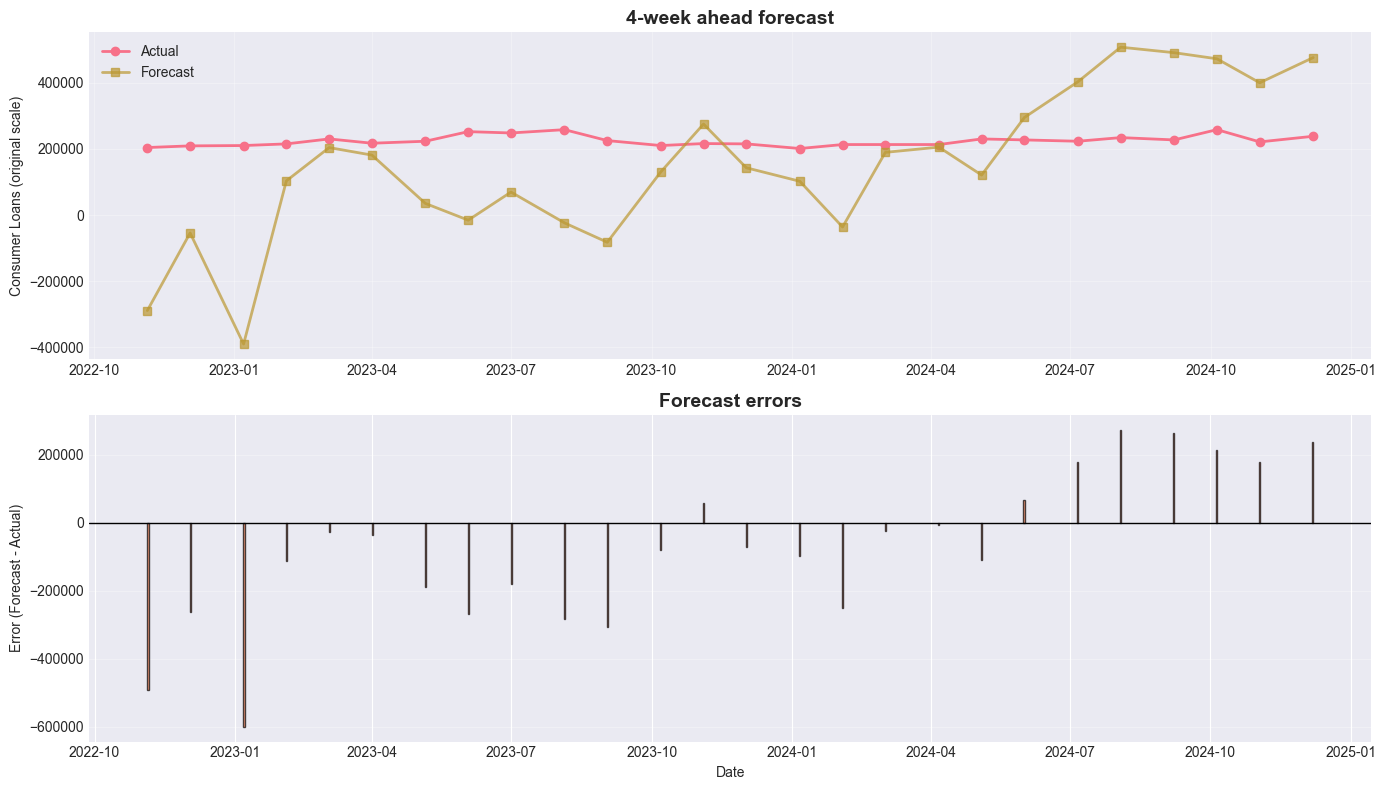

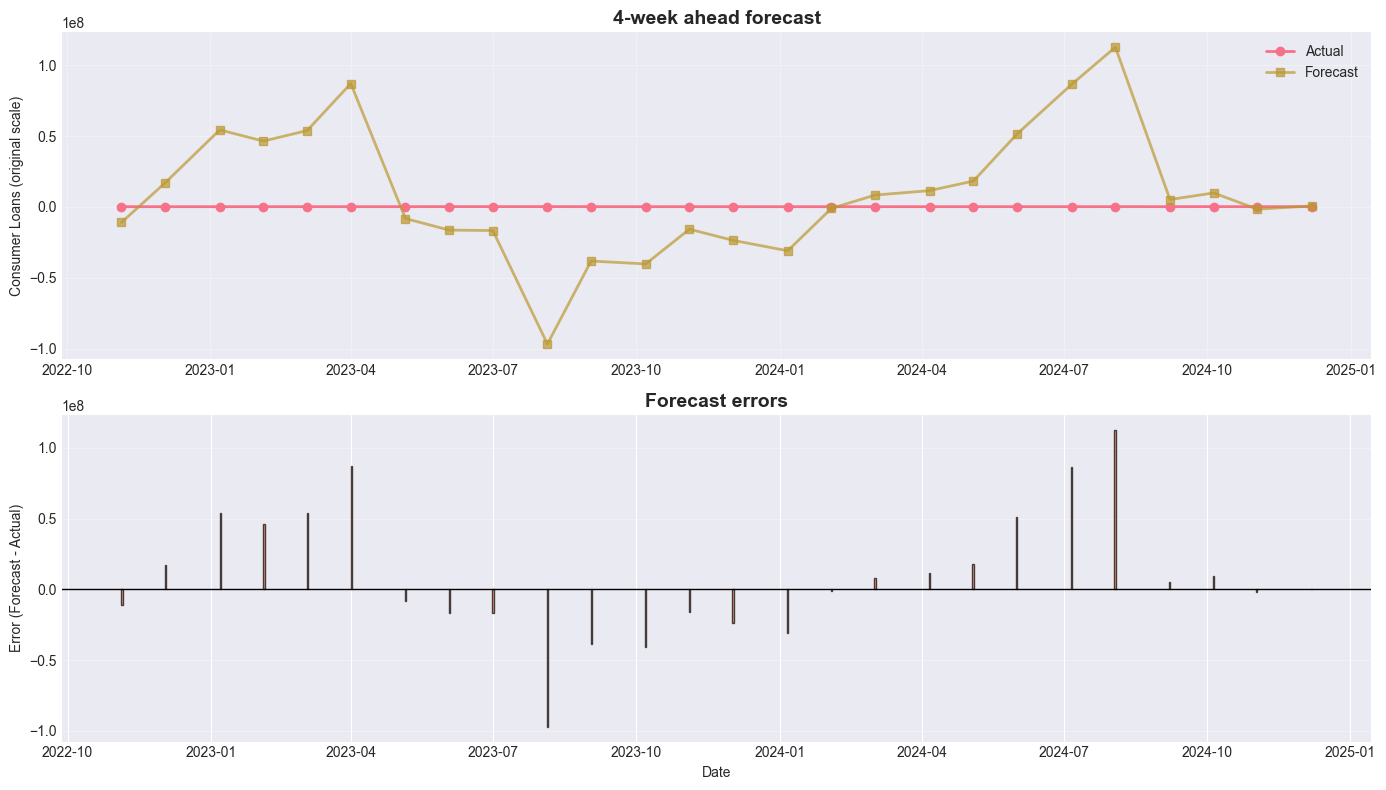

,target_date,actual_orig,signature_y_only,signature_joint
0,2022-11-05,204000.0,-288568.738470,-1.095025e+07
1,2022-12-03,209000.0,-54164.239797,1.708625e+07
2,2023-01-07,210000.0,-389715.084694,5.445766e+07
3,2023-02-04,215000.0,103333.577524,4.654258e+07
4,2023-03-04,230000.0,203819.312554,5.398195e+07


In [9]:
delta_t = INITIAL_CLAIMS_PLOT_HORIZON
val_start_t = len(y) - INITIAL_CLAIMS_N_VALIDATION - delta_t
val_end_t = len(y) - delta_t - 1

forecast_y_only = rolling_forecast(
    X=X,
    y=y,
    start_t=val_start_t,
    end_t=val_end_t,
    delta_t=delta_t,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    lambda_lasso=None,
    gamma=None,
    n_target=N_TARGET,
    use_sig_y_only=True,
    add_time=True,
)

forecast_joint = rolling_forecast(
    X=X,
    y=y,
    start_t=val_start_t,
    end_t=val_end_t,
    delta_t=delta_t,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    lambda_lasso=None,
    gamma=None,
    n_target=N_TARGET,
    use_sig_y_only=False,
    add_time=True,
)

metrics_y_only = inverse_transform_forecasts(forecast_y_only, y_scaler)
metrics_joint = inverse_transform_forecasts(forecast_joint, y_scaler)

df_y_only = build_forecast_dataframe(forecast_y_only, dates, delta_t, metrics_y_only)
df_joint = build_forecast_dataframe(forecast_joint, dates, delta_t, metrics_joint)

plot_forecast_vs_actual(df_y_only, delta_t)
plot_forecast_vs_actual(df_joint, delta_t)

plot_df = df_y_only[["target_date", "actual_orig"]].merge(
    df_y_only[["target_date", "forecast_orig"]].rename(columns={"forecast_orig": "signature_y_only"}),
    on="target_date",
    how="left",
).merge(
    df_joint[["target_date", "forecast_orig"]].rename(columns={"forecast_orig": "signature_joint"}),
    on="target_date",
    how="left",
)

plot_df.to_csv(DATASET_DIR / f"forecast_path_comparison_delta{delta_t}.csv", index=False)
plot_df.head()